In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.power_law_var_g_fitting import PowerLawVarGFitting
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)
fit = PowerLawVarGFitting(
    dp, LAD_min=0,
    sensitivity_model = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg),
    min_alpha_to_consider = 100
    )

In [ ]:
from statsmodels.base.model import GenericLikelihoodModelResults

from boulder_statistics.analysis.fit_params.power_law_var_g_fit_params import PowerLawVarGFitParams

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = PowerLawVarGFitParams(q=0.8, g_mu=0.5, g_std=0.1),
    verbose = False,
    summary = True
)

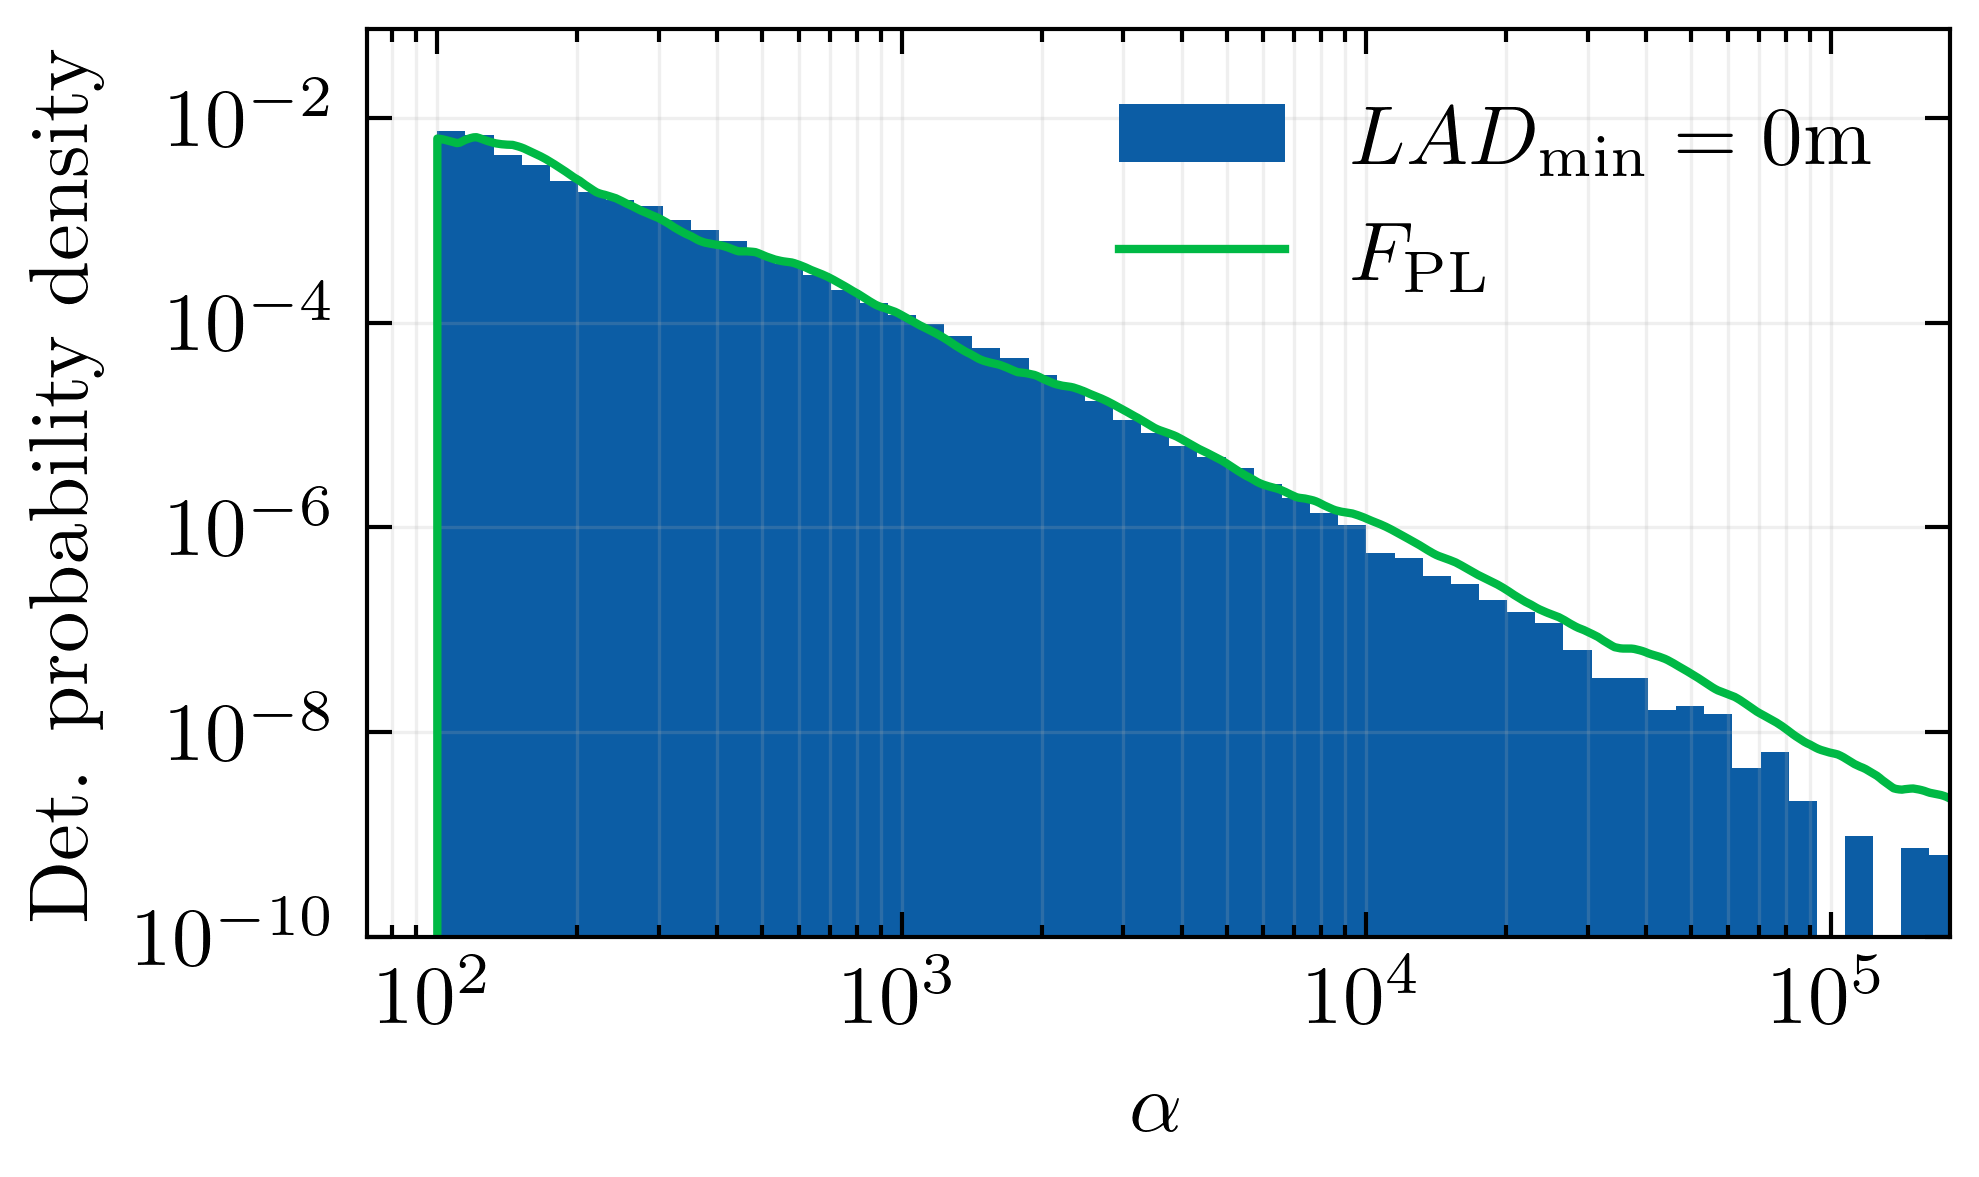

In [ ]:
# 1.6290 0.6006 for LAD min = 2
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_alphas_best_S,
                           alphas_hist, density = True, label = rf"$LAD_{{\text{{min}}}} = {fit.LAD_min}$m")

fit_params = PowerLawVarGFitParams(*mle_model.params)
# fit_params = PowerLawVarGFitParams(q=1.63, g_mu=0.5, g_std=0.1)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_S_function), label = r"$F_{\text{PL}}$")

plt.ylim(1e-10, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
# plt.savefig(f".plots/PL_fit_LAS_gt_{fit.LAD_min}m.png")
plt.show()

In [ ]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/PowerLaw")

while True:
    df = fit.MultiMLEFit(
        optimize_params=fit_params,
        numb_runs=20,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"
    filename.parent.mkdir(parents=True, exist_ok=True)

    df.write_parquet(filename)

    print(f"Saved {filename}")